# Comparative Analysis of Heart Disease Risk Factors
---
A Data Science Approach for Exploring and Comparing Cardiovascular Risk Indicators

Dataset 1 Link source: https://www.kaggle.com/datasets/vishardmehta/heart-risk-progression-dataset


| Feature | Description |
|---|---|
| **Patient_ID** | Unique identifier for each patient |
| **age** | Age of the patient in years |
| **bmi** | Body Mass Index indicating body fat based on height and weight |
| **systolic_bp** | Systolic blood pressure level |
| **diastolic_bp** | Diastolic blood pressure level |
| **cholesterol_mg_dl** | Total cholesterol level measured in mg/dL |
| **resting_heart_rate** | Resting heart rate in beats per minute |
| **smoking_status** | Smoking category (Never, Former, Current) |
| **daily_steps** | Average number of steps taken per day |
| **stress_level** | Stress level on a scale from 1 to 10 |
| **physical_activity_hours_per_week** | Weekly hours of physical exercise |
| **sleep_hours** | Average hours of sleep per night |
| **family_history_heart_disease** | Indicates whether the patient has a family history of heart disease |
| **diet_quality_score** | Score from 1 to 10 representing diet quality |
| **alcohol_units_per_week** | Weekly alcohol consumption |
| **heart_disease_risk_score** | Calculated cardiovascular risk score (0–100) |
| **risk_category** | Risk classification: Low, Medium, or High |

Dataset 2 Link source: https://www.kaggle.com/datasets/fatemehmohammadinia/heart-attack-dataset-tarik-a-rashid

| Feature | Description |
|---|---|
| **Age** | Age of the patient |
| **Gender** | Biological sex of the patient (Male = 1, Female = 0) |
| **Heart Rate** | Number of heartbeats per minute |
| **Systolic Blood Pressure** | Pressure in the arteries when the heart contracts |
| **Diastolic Blood Pressure** | Pressure in the arteries between heartbeats |
| **Blood Sugar** | Blood glucose level of the patient |
| **Ck-mb** | Cardiac enzyme released during heart muscle damage |
| **Troponin** | Highly specific protein biomarker for heart muscle injury |
| **Result** | Target variable indicating whether the patient experienced a heart attack |

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from scipy.stats import pearsonr

In [27]:
cardiovascular_risk_dataset = pd.read_csv('../data/cardiovascular_risk_dataset.csv')
cardiovascular_risk_dataset.columns = cardiovascular_risk_dataset.columns.str.lower()
cardiovascular_risk_dataset

,patient_id,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,smoking_status,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,family_history_heart_disease,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score,risk_category
0,1,62,25.0,142,93,247,72,Never,11565,3,5.6,8.2,No,7,0.7,28.1,Medium
1,2,54,29.7,158,101,254,74,Current,4036,8,0.5,6.7,No,5,4.5,63.0,High
2,3,46,36.2,170,113,276,80,Current,3043,9,0.4,4.0,No,1,20.8,73.1,High
3,4,48,30.4,153,98,230,73,Former,5604,5,0.6,8.0,No,4,8.5,39.5,Medium
4,5,46,25.3,139,87,206,69,Current,7464,1,2.0,6.1,No,5,3.6,29.3,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5495,5496,19,26.0,121,75,185,84,Never,6724,3,2.9,7.2,No,7,0.0,0.0,Low
5496,5497,18,30.9,128,82,235,75,Never,3661,4,0.0,5.5,No,1,9.6,16.8,Low
5497,5498,63,29.5,142,92,239,69,Never,6643,5,4.1,6.9,No,6,2.4,31.8,Medium
5498,5499,46,27.5,138,91,237,65,Never,3279,3,2.4,5.8,Yes,5,2.3,29.4,Medium


In [28]:
cardiovascular_risk_dataset['family_history_heart_disease'].value_counts()

family_history_heart_disease
No     4134
Yes    1366
Name: count, dtype: int64

In [29]:
cardiovascular_risk_dataset['smoking_status'].value_counts()

smoking_status
Never      3627
Current     994
Former      879
Name: count, dtype: int64

In [30]:
cardiovascular_risk_dataset['risk_category'].value_counts()

risk_category
Medium    2244
Low       1838
High      1418
Name: count, dtype: int64

With this step below, we examine how the risk score separates patients into the three different risk categories.

In [31]:
cardiovascular_risk_dataset[cardiovascular_risk_dataset['risk_category'] == 'Low']['heart_disease_risk_score'].max()

np.float64(24.9)

In [32]:
cardiovascular_risk_dataset[cardiovascular_risk_dataset['risk_category'] == 'Medium']['heart_disease_risk_score'].max()

np.float64(54.9)

### Dataset Hypotheses
---

#### Hypothesis 1 - Age and Heart Disease

- **H0 (Null Hypothesis):** There is no relationship between age and heart disease risk.
- **H1 (Alternative Hypothesis):** Older people are more likely to suffer from heart disease.



#### Hypothesis 2 - BMI and Heart Disease

- **H0 (Null Hypothesis):** BMI has no relationship with heart disease risk.
- **H1 (Alternative Hypothesis):** People with higher BMI are more likely to suffer from heart disease.



#### Hypothesis 3 - Blood Pressure and Heart Disease

- **H0 (Null Hypothesis):** Blood pressure has no relationship with heart disease risk.
- **H1 (Alternative Hypothesis):** People with higher blood pressure are more likely to suffer from heart disease.



#### Hypothesis 4 - Sleep and Heart Disease

- **H0 (Null Hypothesis):** Sleep duration has no relationship with heart disease risk.
- **H1 (Alternative Hypothesis):** People with fewer hours of sleep are more likely to suffer from heart disease.



#### Hypothesis 5 - Stress and Heart Disease

- **H0 (Null Hypothesis):** Stress level has no relationship with heart disease risk.
- **H1 (Alternative Hypothesis):** People with higher stress levels are more likely to suffer from heart disease.



#### Hypothesis 6 - Alcohol Consumption and Heart Disease

- **H0 (Null Hypothesis):** Alcohol consumption has no relationship with heart disease risk.
- **H1 (Alternative Hypothesis):** Frequent alcohol consumption increases the likelihood of heart disease.

In [33]:
crd = cardiovascular_risk_dataset.copy()

In [34]:
medical_dataset = pd.read_csv('../data/Medicaldataset.csv')
medical_dataset.columns = medical_dataset.columns.str.lower()
medical_dataset

,age,gender,heart rate,systolic blood pressure,diastolic blood pressure,blood sugar,ck-mb,troponin,result
0,64,1,66,160,83,160.0,1.80,0.012,negative
1,21,1,94,98,46,296.0,6.75,1.060,positive
2,55,1,64,160,77,270.0,1.99,0.003,negative
3,64,1,70,120,55,270.0,13.87,0.122,positive
4,55,1,64,112,65,300.0,1.08,0.003,negative
...,...,...,...,...,...,...,...,...,...
1314,44,1,94,122,67,204.0,1.63,0.006,negative
1315,66,1,84,125,55,149.0,1.33,0.172,positive
1316,45,1,85,168,104,96.0,1.24,4.250,positive
1317,54,1,58,117,68,443.0,5.80,0.359,positive


In [35]:
medical_dataset['result'].value_counts()

result
positive    810
negative    509
Name: count, dtype: int64

The check shows that the dataset is imbalanced, with a higher number of observations belonging to patients with heart disease.

#### Hypothesis 7 — Gender and Heart Disease

- **H0 (Null Hypothesis):** Gender has no relationship with heart disease risk.
- **H1 (Alternative Hypothesis):** Men are more likely to suffer from heart disease.

In [36]:
medical_dataset['result'] = medical_dataset['result'].map({
    'positive': 1,
    'negative': 0
})

In [37]:
md = medical_dataset.copy()

### Data verification

In [38]:
#Checking the shape of the dataset
crd.shape

(5500, 17)

In [39]:
# Checking entire dataset for null values
crd.isnull().values.any()

np.False_

In [40]:
#Checking the shape of the dataset
md.shape

(1319, 9)

In [41]:
# Checking entire dataset for null values
md.isnull().values.any()

np.False_

### Descriptive Statistics

In [42]:
# Checking the age of the people (observations) in the data
crd.describe()

,patient_id,age,bmi,systolic_bp,diastolic_bp,cholesterol_mg_dl,resting_heart_rate,daily_steps,stress_level,physical_activity_hours_per_week,sleep_hours,diet_quality_score,alcohol_units_per_week,heart_disease_risk_score
count,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000
mean,2750.500000,53.872000,28.170818,147.248182,95.756727,239.684182,74.075091,5902.929455,4.907091,3.299364,6.869364,5.162909,3.782200,37.540455
std,1587.857571,21.196017,4.189877,13.222701,9.451559,28.570177,6.392166,3041.084590,2.298173,2.672457,1.091263,2.286134,3.515594,24.287026
min,1.000000,18.000000,15.000000,108.000000,64.000000,147.000000,48.000000,500.000000,1.000000,0.000000,4.000000,1.000000,0.000000,0.000000
25%,1375.750000,36.000000,25.200000,138.000000,89.000000,220.000000,70.000000,3428.000000,3.000000,1.200000,6.200000,3.000000,1.200000,18.400000
50%,2750.500000,54.000000,28.400000,147.000000,96.000000,240.000000,74.000000,5460.000000,5.000000,2.600000,6.900000,5.000000,2.800000,36.700000
75%,4125.250000,72.000000,31.100000,156.000000,102.000000,260.000000,79.000000,7772.000000,7.000000,4.900000,7.600000,7.000000,5.300000,55.500000
max,5500.000000,90.000000,40.900000,192.000000,120.000000,331.000000,92.000000,16793.000000,10.000000,12.900000,10.000000,10.000000,29.200000,100.000000


In [43]:
md.describe()

,age,gender,heart rate,systolic blood pressure,diastolic blood pressure,blood sugar,ck-mb,troponin,result
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,56.191812,0.659591,78.336619,127.170584,72.269143,146.634344,15.274306,0.360942,0.614102
std,13.647315,0.474027,51.630270,26.122720,14.033924,74.923045,46.327083,1.154568,0.486991
min,14.000000,0.000000,20.000000,42.000000,38.000000,35.000000,0.321000,0.001000,0.000000
25%,47.000000,0.000000,64.000000,110.000000,62.000000,98.000000,1.655000,0.006000,0.000000
50%,58.000000,1.000000,74.000000,124.000000,72.000000,116.000000,2.850000,0.014000,1.000000
75%,65.000000,1.000000,85.000000,143.000000,81.000000,169.500000,5.805000,0.085500,1.000000
max,103.000000,1.000000,1111.000000,223.000000,154.000000,541.000000,300.000000,10.300000,1.000000


From the perspective of age distribution, the selected observations in both datasets appear relatively similar. Some differences can still be observed, but this is generally unavoidable in most real-world datasets.

### Data Analysis

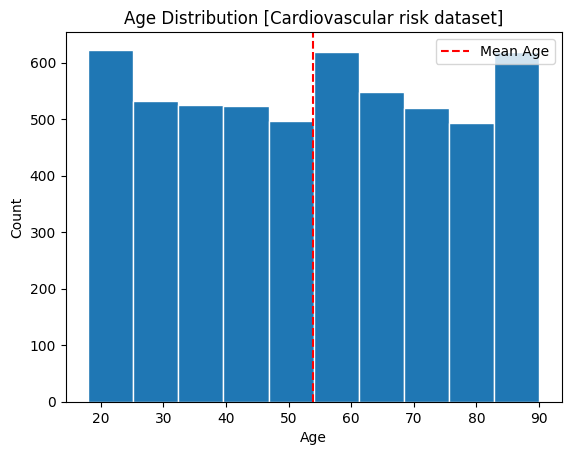

In [44]:
plt.hist(crd['age'], edgecolor='white', bins=10)

mean_age = crd['age'].mean()

plt.axvline(mean_age, color='red', linestyle='--', label='Mean Age')

plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution [Cardiovascular risk dataset]')

plt.legend()

plt.show()

The age distribution appears relatively balanced across the dataset, with observations spread throughout all age groups. No extreme concentration in a specific age interval can be observed.

The average age is ~55, indicating that the dataset mainly focuses on middle-aged and older individuals, which is reasonable in the context of cardiovascular risk analysis.

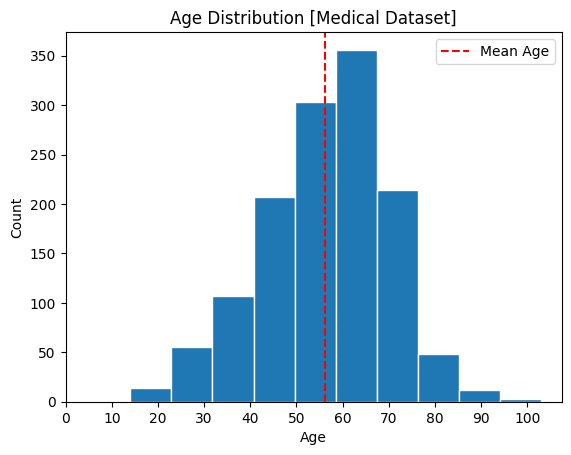

In [45]:
plt.hist(md['age'], edgecolor='white', bins=10)

mean_age = md['age'].mean()

plt.axvline(mean_age, color='red', linestyle='--', label='Mean Age')

plt.xlabel('Age')
plt.ylabel('Count')

plt.xticks(range(0, 101, 10))

plt.title('Age Distribution [Medical Dataset]')

plt.legend()

plt.show()

The age distribution in this dataset appears approximately normal, with most observations concentrated between the ages of 45 and 70.

The average age is around 55, suggesting that the dataset mainly includes middle-aged and older individuals. Very young and very old patients are relatively rare in the dataset.

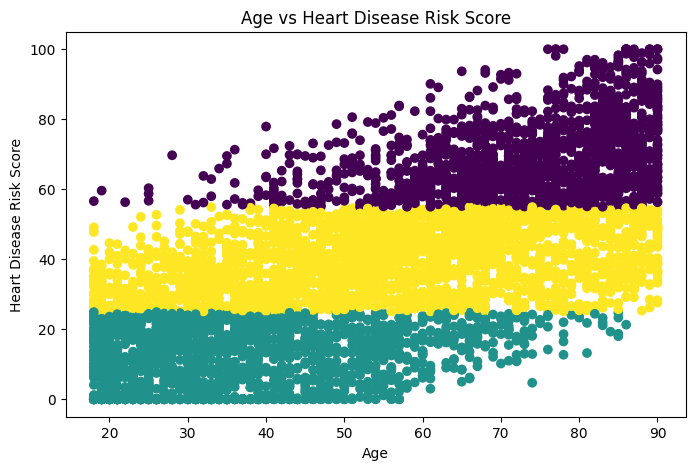

In [46]:
# Scatter plot showing the relationship between age
# and heart disease risk score.

# Each point represents a single patient.

# The colors indicate the patient's risk category
# (Low, Medium, High).

# This visualization helps identify whether
# older patients tend to have higher cardiovascular risk.
plt.figure(figsize=(8,5))

plt.scatter(
    cardiovascular_risk_dataset['age'],
    cardiovascular_risk_dataset['heart_disease_risk_score'],
    c=cardiovascular_risk_dataset['risk_category'].astype('category').cat.codes
)

plt.xlabel('Age')
plt.ylabel('Heart Disease Risk Score')
plt.title('Age vs Heart Disease Risk Score')

plt.show()

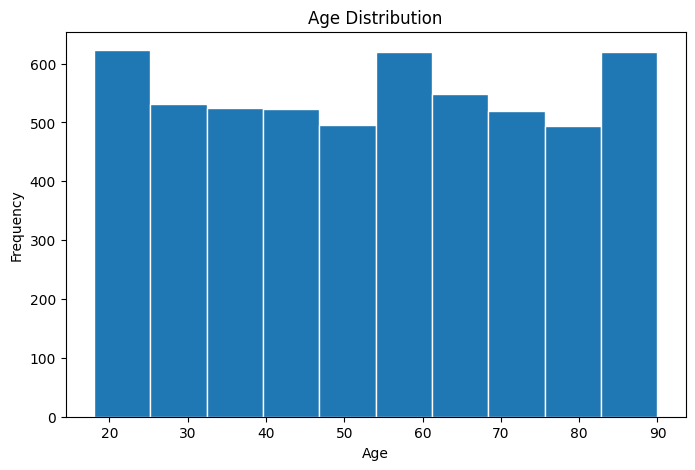

In [56]:
# Age Distribution Visualization
# A histogram was created to examine the distribution of the `age` feature in the dataset.
# Understanding the distribution of the `age` variable is important before performing statistical analysis because many statistical methods, including Pearson correlation, work more reliably when the data does not contain extreme irregularities.
plt.figure(figsize=(8,5))

plt.hist(crd['age'], bins=10, edgecolor='white')

plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')

plt.show()

The histogram shows a relatively balanced distribution of age values across the dataset.

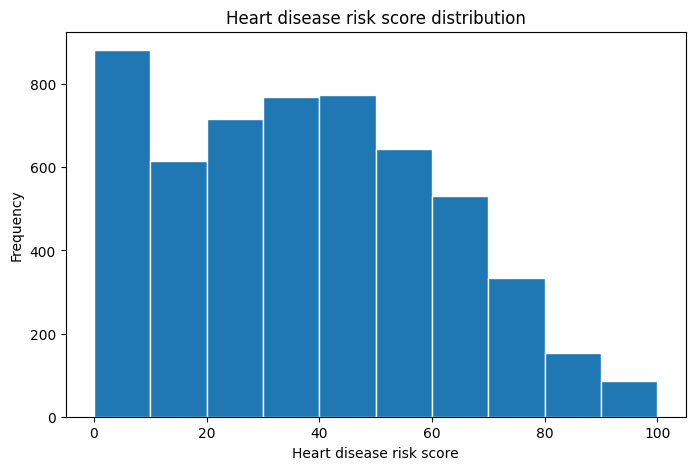

In [58]:
plt.figure(figsize=(8,5))

plt.hist(crd['heart_disease_risk_score'], bins=10, edgecolor='white')

plt.xlabel('Heart disease risk score')
plt.ylabel('Frequency')
plt.title('Heart disease risk score distribution')

plt.show()

The distribution of the heart disease risk score is moderately right-skewed. Lower and medium risk scores appear more frequently, while very high risk scores are less common in the dataset.

Pearson Correlation Analysis

In this analysis, Pearson correlation was used to examine the relationship between `age` and `heart_disease_risk_score`.

Pearson correlation is appropriate because both variables are numerical and their distributions appear relatively balanced without extreme skewness or abnormal concentration of values.

In [49]:
corr, p_value = pearsonr(
    cardiovascular_risk_dataset['age'],
    cardiovascular_risk_dataset['heart_disease_risk_score']
)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.6942860722556741
P-value: 0.0


The correlation coefficient indicates a strong positive linear relationship between age and heart disease risk score.

This means that, in general, as age increases, the heart disease risk score also tends to increase.

Additionally, the p-value is significantly lower than the standard significance threshold of `0.05`, meaning that the relationship is statistically significant.

Therefore:

- The null hypothesis (`H0`) is rejected.
- The alternative hypothesis (`H1`) is accepted - `Older people are more likely to suffer from heart disease.`